In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [61]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data)

In [62]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

eda

In [64]:
df.shape

(20640, 8)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       20640 non-null  float64
 1   1       20640 non-null  float64
 2   2       20640 non-null  float64
 3   3       20640 non-null  float64
 4   4       20640 non-null  float64
 5   5       20640 non-null  float64
 6   6       20640 non-null  float64
 7   7       20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [66]:
df.describe()

,0,1,2,3,4,5,6,7
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [33]:
df.isnull().sum()

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64

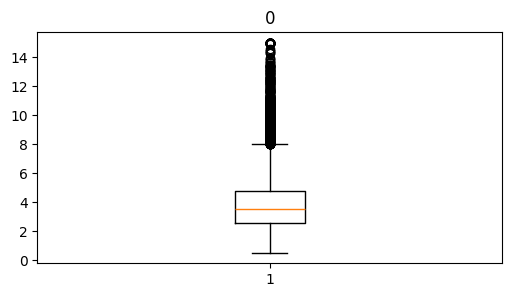

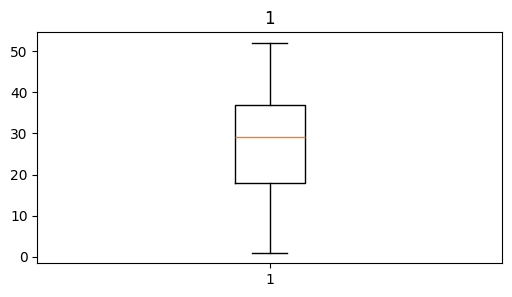

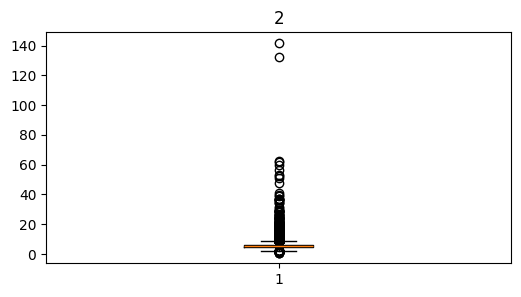

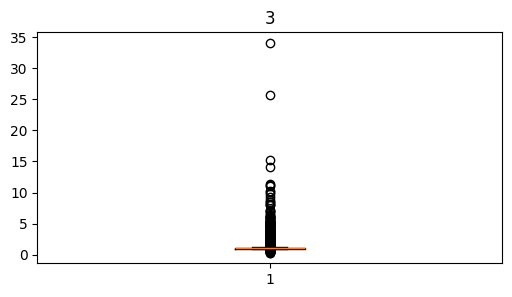

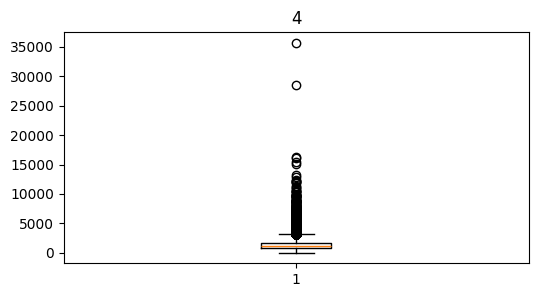

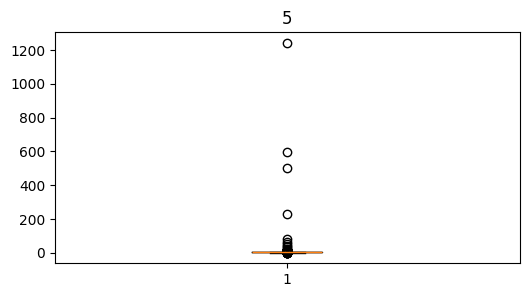

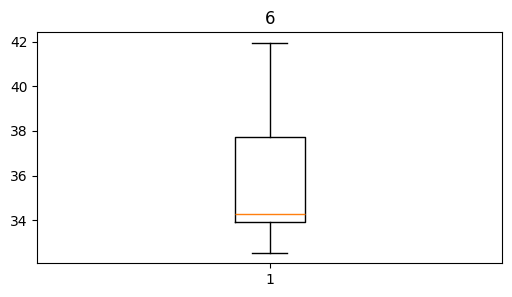

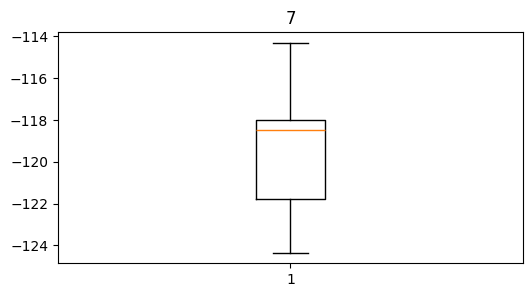

In [35]:
import matplotlib.pyplot as plt

for col in df.columns:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

In [67]:
print(df.columns)

RangeIndex(start=0, stop=8, step=1)


to know about distribution nature of colums

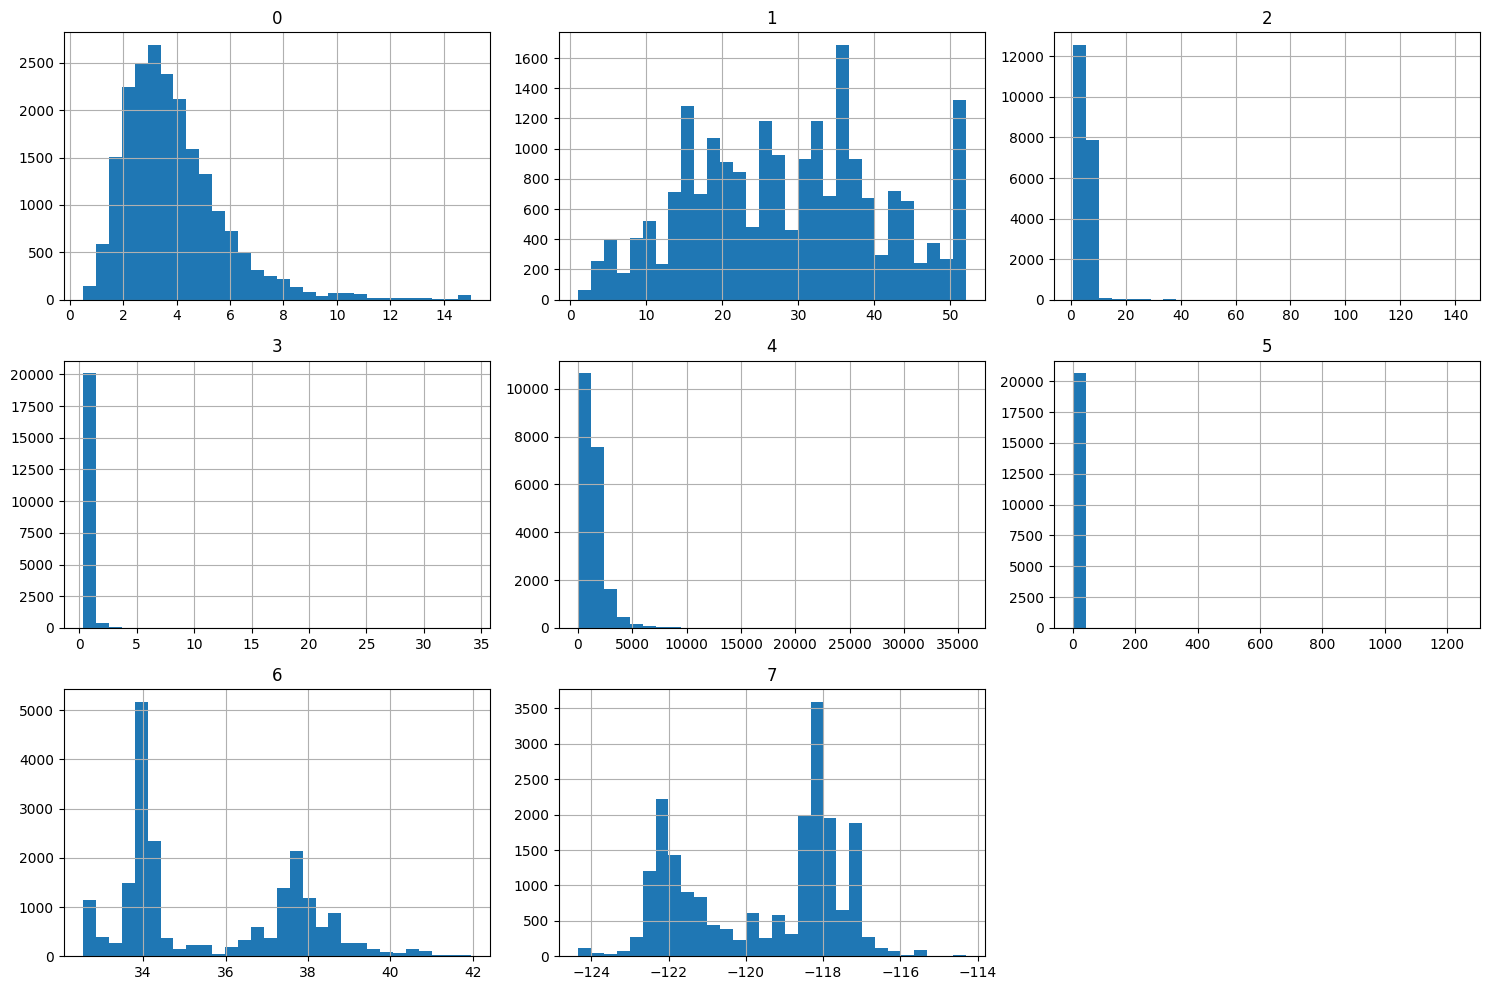

In [68]:
import matplotlib.pyplot as plt

df.hist(figsize=(15,10), bins=30)

plt.tight_layout()

plt.show()

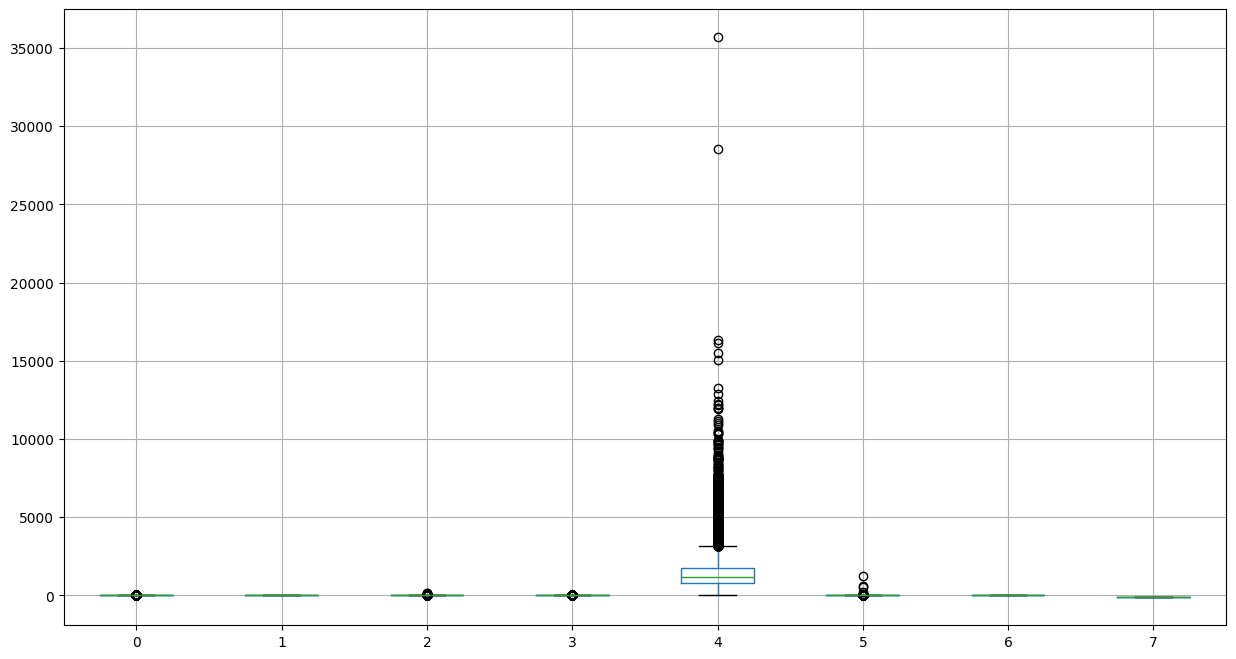

In [69]:
plt.figure(figsize=(15,8))

df.boxplot()

plt.show()

finding outliers

In [70]:
for col in df.columns:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        f"Column {col}: {len(outliers)} outliers"
    )

Column 0: 681 outliers
Column 1: 0 outliers
Column 2: 511 outliers
Column 3: 1424 outliers
Column 4: 1196 outliers
Column 5: 711 outliers
Column 6: 0 outliers
Column 7: 0 outliers


corelation analysis

In [71]:
corr = df.corr()

corr

,0,1,2,3,4,5,6,7
0,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
1,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
2,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
3,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
4,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
5,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
6,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
7,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


Correlation	Meaning
>0.8	Strong


0.5-0.8	Moderate


<0.5	Weak

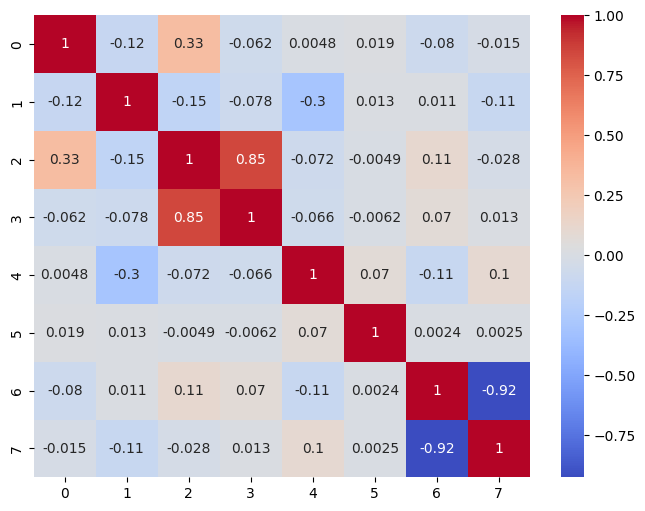

In [46]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [48]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.2 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.5 MB 1.2 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.5 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.5 MB 1.3 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.5 MB 868.7 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.5 MB 868.7 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.5 MB 868.7 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.5 MB 868.7 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.5 MB 868.7 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.5 MB 868.7 kB/s eta 0:00:10
   ------ -----------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = df.columns

vif["VIF"] = [
    variance_inflation_factor(
        df.values,
        i
    )
    for i in range(df.shape[1])
]

vif

,Feature,VIF
0,0,11.511140
1,1,7.195917
2,2,45.993601
3,3,43.590314
4,4,2.935745
5,5,1.095243
6,6,559.874071
7,7,633.711654


In [73]:
X = df
y = data.target

In [74]:
print(X.columns)

RangeIndex(start=0, stop=8, step=1)


In [76]:
print(y)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df,
    y,
    test_size=0.2,
    random_state=42
)

In [78]:
X_train

,0,1,2,3,4,5,6,7
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [81]:
X_train_scaled

array([[-0.326196  ,  0.34849025, -0.17491646, ...,  0.05137609,
        -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, ..., -0.11736222,
        -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, ..., -0.03227969,
        -0.46014647, -0.44760309],
       ...,
       [-0.49697313,  0.58654547, -0.60675918, ...,  0.02030568,
        -0.75500738,  0.59946887],
       [ 0.96545045, -1.07984112,  0.40217517, ...,  0.00707608,
         0.90651045, -1.18553953],
       [-0.68544764,  1.85617335, -0.85144571, ..., -0.08535429,
         0.99543676, -1.41489815]], shape=(16512, 8))

In [80]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [82]:
y_pred = lr.predict(
    X_test_scaled
)

In [83]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2:", r2)

MAE: 0.5332001304956564
RMSE: 0.7455813830127764
R2: 0.5757877060324508


In [84]:
residuals = y_test - y_pred

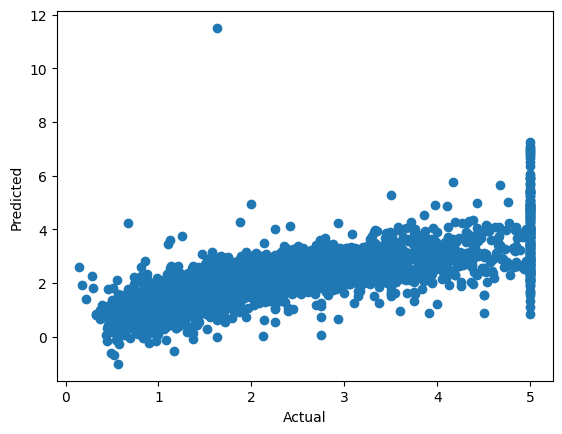

In [85]:
plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.show()

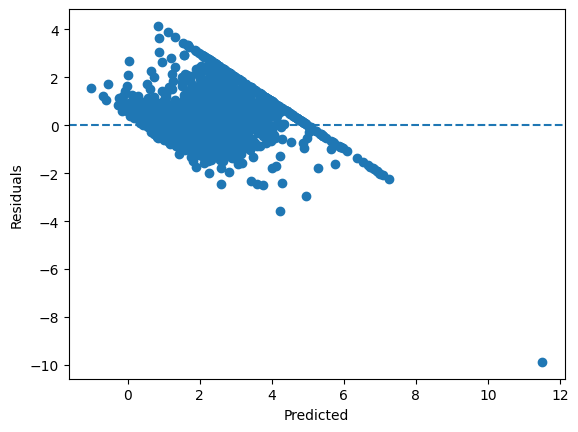

In [86]:
plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.show()

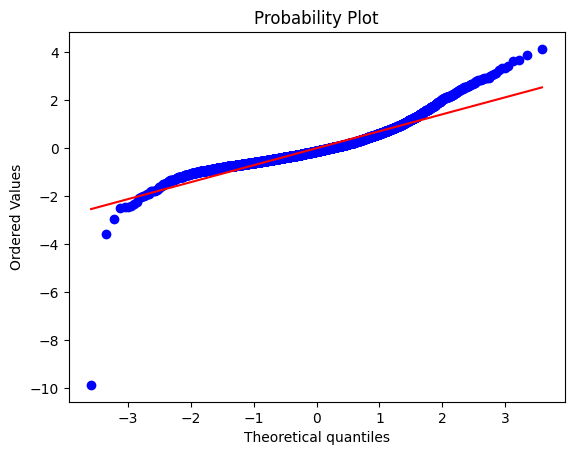

In [87]:
import scipy.stats as stats

stats.probplot(
    residuals,
    dist='norm',
    plot=plt
)

plt.show()

In [89]:
from statsmodels.stats.stattools import durbin_watson

durbin_watson(
    residuals
)

np.float64(2.040741738727076)